## __MCDI - SEMANA 4__
### __Datos__:
#### __Grupo:__ 8
#### __Fecha:__ 21/06/2026
#### __Curso:__ MCDI500.202681.2556

In [1]:
#Librerías a usar en el proyecto.
import pandas as pd
import time
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt

### __Clase Abstracta Base.__
#### __Descripción:__ Clase abstracta que define el comportamiento común para cualquier conjunto de datos financieros... Obliga a las clases hijas a implementar las etapas de carga, limpieza, preparación y validación.

In [2]:
class FinancialDataset(ABC):
    def __init__(self, archivo):
        #Encapsulamiento: La ruta del archivo y el DataFrame se almacenan como atributos protegidos.
        self._archivo = archivo
        self._df = None

    @abstractmethod
    def cargar(self):
        pass

    @abstractmethod
    def limpiar(self):
        pass

    @abstractmethod
    def preparar(self):
        pass

    @abstractmethod
    def validar(self):
        pass
    
    #Retorna una copia del DataFrame para evitar modificaciones externas sobre el original.
    def obtener_dataframe(self):
        return self._df.copy()

### __Dataset Bitcoin.__
#### __Descripción:__ Implementación concreta para el análisis de datos históricos del Bitcoin.

In [3]:
class BitcoinDataset(FinancialDataset):
    def cargar(self):
        #Inicio del proceso de carga.
        print("Cargando datos...")
        #Lectura del archivo CSV.
        #Se especifican: Codificación, Tipos de datos y Conversión automática de fechas.
        self._df = pd.read_csv(
            self._archivo,
            encoding="utf-8",
            dtype={
                "Open": "float64",
                "High": "float64",
                "Low": "float64",
                "Close": "float64",
                "Adj Close": "float64",
                "Volume": "int64"
            },
            parse_dates=["Date"]
        )
        #Validación básica de carga.
        #Verifica que el archivo contenga registros.
        if self._df.empty:
            raise ValueError("El archivo fue cargado pero no contiene registros.")
        #Mensaje de confirmación.
        print(f"Datos cargados correctamente: {len(self._df)} registros.")

    def limpiar(self):
        print("Limpiando datos...")
        #Asegura que la columna Date sea tratada como un tipo de dato fecha.
        self._df["Date"] = pd.to_datetime(self._df["Date"])
        #Ordena cronológicamente los registros... Es fundamental para análisis de series temporales.
        self._df = self._df.sort_values("Date")
        #Identificación automática de columnas numéricas.
        columnas_numericas = (self._df.select_dtypes(include="number").columns)
        #Revisión de valores faltantes.
        for columna in columnas_numericas:
            #Cantidad de registros nulos.
            cantidad_nulos = (self._df[columna].isna().sum())
            if cantidad_nulos > 0:
                #Cálculo del promedio utilizando únicamente los valores válidos.
                promedio = (self._df[columna].mean())
                #Reemplazo de valores faltantes.
                self._df[columna] = (self._df[columna].fillna(promedio))
                #Registro de los cambios realizados.
                print(
                    f"{columna}: {cantidad_nulos} nulos reemplazados por {promedio:.2f}."
                )
        #Eliminación de registros duplicados.
        self._df = (self._df.drop_duplicates())

    def preparar(self):
        print("Preparando datos...")
        #La fecha pasa a ser el índice principal.
        self._df = (self._df.set_index("Date"))
        #Retorno porcentual diario respecto al precio de cierre anterior.
        self._df["Return"] = (self._df["Close"].pct_change().fillna(0))
        #Diferencia absoluta entre apertura y cierre.
        self._df["Price_Diff"] = (self._df["Close"] - self._df["Open"])
        #Medida de volatilidad diaria.
        self._df["Volatility"] = ((self._df["High"] - self._df["Low"]) / self._df["Open"]) * 100
        #Media móvil de corto plazo.
        self._df["MA_7"] = (self._df["Close"].rolling(window=7,min_periods=1).mean())
        #Media móvil de mediano plazo.
        self._df["MA_30"] = (self._df["Close"].rolling(window=30,min_periods=1).mean())
        #Volumen promedio móvil.
        self._df["Volume_MA30"] = (self._df["Volume"].rolling(window=30,min_periods=1).mean())

    def validar(self):
        print("\nValidaciones:")
        #Regla de negocio: El precio de apertura no puede ser negativo.
        open_negativo = (self._df["Open"] < 0).sum()
        #Regla de negocio: El máximo diario debe ser mayor o igual al mínimo.
        high_menor_low = (self._df["High"] < self._df["Low"]).sum()
        #Regla de negocio: El volumen no puede ser negativo.
        volumen_negativo = (self._df["Volume"] < 0).sum()
        #Mensajes de reglas de negocio.
        print(f"Open negativos: {open_negativo}.")
        print(f"High < Low: {high_menor_low}.")
        print(f"Volume negativos: {volumen_negativo}")

### __Segundo Dataset para Polimorfismo (Ejemplo).__
#### __Descripción:__ Clase utilizada únicamente para demostrar el concepto de polimorfismo.

In [4]:
class StockDataset(FinancialDataset):
    def cargar(self):
        print("Carga de acciones...")

    def limpiar(self):
        print("Limpieza de acciones...")

    def preparar(self):
        print("Preparación de acciones...")

    def validar(self):
        print("Validación de acciones...")

### __Pipeline.__
#### __Descripción:__ Orquesta la ejecución secuencial de las etapas del procesamiento.

In [5]:
class DataPipeline:
    def __init__(self, dataset):
        self.dataset = dataset
        
    def ejecutar(self):
        self.dataset.cargar()
        self.dataset.limpiar()
        self.dataset.preparar()
        self.dataset.validar()
        return self.dataset

### __Complejidad Computacional.__

In [6]:
class ComplejidadAnalisis:
    @staticmethod
    def media_movil_pandas(df):
        #Medición de tiempo de ejecución utilizando funciones optimizadas de Pandas.
        inicio = time.perf_counter()
        resultado = (df["Close"].rolling(30).mean())
        fin = time.perf_counter()
        print(f"Pandas O(n): {fin - inicio:.6f} segundos.")
        return resultado
    
    @staticmethod
    def media_movil_manual(df):
        #Implementación manual utilizada para comparar tiempos de ejecución.
        inicio = time.perf_counter()
        resultado = []
        for i in range(len(df)):
            promedio = (df["Close"].iloc[max(0, i - 29): i + 1].mean())
            resultado.append(promedio)
        fin = time.perf_counter()
        print(f"Manual O(n²): {fin - inicio:.6f} segundos."
        )
        return resultado

### __Programa Principal.__
#### __Descripción:__ Ejecución del programa principal que llama a nuestros métodos.

In [7]:
if __name__ == "__main__":
    #Carga del dataset.
    bitcoin = BitcoinDataset("bitcoin_dataset.csv")
    #Creación y ejecución del pipeline.
    pipeline = DataPipeline(bitcoin)
    pipeline.ejecutar()
    #Obtención del DataFrame final.
    df_final = (bitcoin.obtener_dataframe())
    print("\nPrimeros registros:")
    print(df_final.head())  #5 registros por defecto.
    print("\nÚltimos registros:")
    print(df_final.tail())  #5 registros por defecto.
    #Comparación de complejidad computacional.
    print("\nComparación de complejidad:")
    ComplejidadAnalisis.media_movil_pandas(df_final)
    ComplejidadAnalisis.media_movil_manual(df_final)

Cargando datos...
Datos cargados correctamente: 4280 registros.
Limpiando datos...
Preparando datos...

Validaciones:
Open negativos: 0.
High < Low: 0.
Volume negativos: 0

Primeros registros:
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2014-09-17  465.864014  468.174011  452.421997  457.334015  457.334015   
2014-09-18  456.859985  456.859985  413.104004  424.440002  424.440002   
2014-09-19  424.102997  427.834991  384.532013  394.795990  394.795990   
2014-09-20  394.673004  423.295990  389.882996  408.903992  408.903992   
2014-09-21  408.084991  412.425995  393.181000  398.821014  398.821014   

              Volume    Return  Price_Diff  Volatility        MA_7  \
Date                                                                 
2014-09-17  21056800  0.000000   -8.529999    3.381247  457.334015   
2014-09-18  34483200 -0.071926  -32.419983    9.577547  440.887009   
2014-09-

### __Análisis de Evolución del Precio.__
#### __Descripción:__ Visualiza el precio de cierre junto a las medias móviles, nos permite identificar tendencias de corto y mediano plazo.

#### __Interpretación:__
##### MA_7 sobre MA_30: Tendencia alcista.
##### MA_7 bajo MA_30: Tendencia bajista.

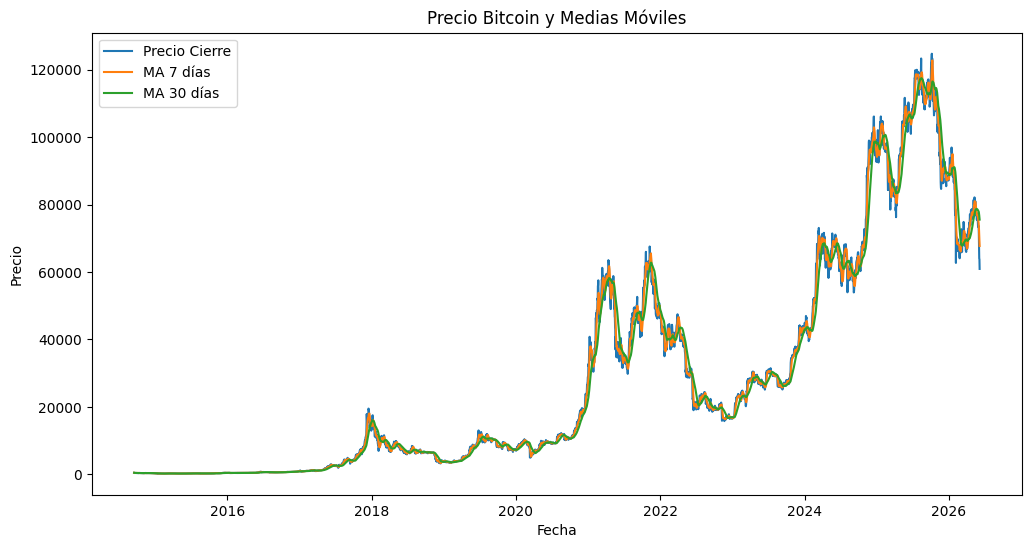

In [8]:
plt.figure(figsize=(12,6))
plt.plot(
    df_final.index,
    df_final["Close"],
    label="Precio Cierre"
)
plt.plot(
    df_final.index,
    df_final["MA_7"],
    label="MA 7 días"
)
plt.plot(
    df_final.index,
    df_final["MA_30"],
    label="MA 30 días"
)
plt.title("Precio Bitcoin y Medias Móviles")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.show()

### __Análisis de Rentabilidad.__
#### __Descripción:__ Estadísticas descriptivas de los retornos diarios e Histograma de retornos... Permite identificar dispersión, concentración y eventos extremos.

Descripción de campo Return (Estadísticas):
count    4280.000000
mean        0.001758
std         0.034912
min        -0.371695
25%        -0.012613
50%         0.001062
75%         0.015879
max         0.252472
Name: Return, dtype: float64


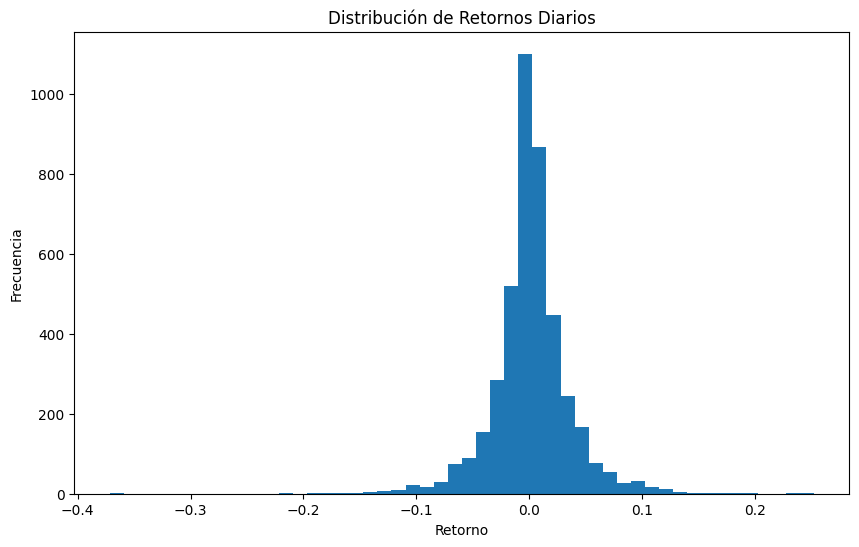

In [9]:
print("Descripción de campo Return (Estadísticas):")
print(df_final["Return"].describe())
plt.figure(figsize=(10,6))
plt.hist(
    df_final["Return"],
    bins=50
)
plt.title(
    "Distribución de Retornos Diarios"
)
plt.xlabel("Retorno")
plt.ylabel("Frecuencia")
plt.show()

### __Análisis de Volatidad.__
#### __Descripción:__ Representa la evolución temporal de la volatilidad, donde los picos de datos suelen indicar períodos de incertidumbre o movimientos bruscos del mercado.

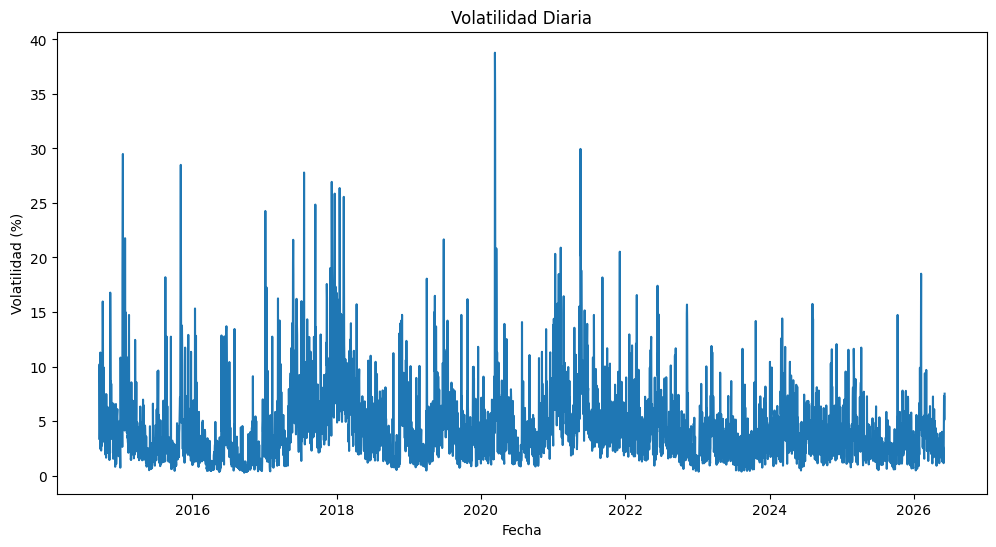

In [10]:
plt.figure(figsize=(12,6))
plt.plot(
    df_final.index,
    df_final["Volatility"]
)
plt.title(
    "Volatilidad Diaria"
)
plt.xlabel("Fecha")
plt.ylabel("Volatilidad (%)")
plt.show()